# Machine Learning - K-Means

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

- **species:** Espécie do pinguim (Adelie (0), Chinstrap(1), Gentoo(2))

- **island:** Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

- **bill_length_mm:** Comprimento do bico em milímetros

- **bill_depth_mm:** Profundidade do bico em milímetros

- **flipper_length_mm:** Comprimento da barbatana em milímetros

- **body_mass_g:** Massa corporal em gramas

- **sex:** Sexo do pinguim (Male, Female)

- **year:** Ano em que a observação foi feita

In [394]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [395]:
pinguins = sns.load_dataset('penguins')

Foi realizado o download do dataset para coloca-lo na pasta do Github, com o projeto completo:

In [396]:
pinguins.to_csv('pinguins.csv', index=False)

In [397]:
pinguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# Verificação de variáveis faltantes e exclusão desses valores do dataset, também devem exclusão/alteração das colunas com valores categóricos

**Mudança dos valores categoricos:**

In [398]:
species_ok = {'Adelie':0, 'Chinstrap':1, 'Gentoo':2}

pinguins['species'] = pinguins['species'].replace(species_ok)

In [399]:
pinguins= pinguins.drop('island',axis=1)


pinguins= pinguins.drop('species',axis=1)

In [400]:
pinguins= pinguins.drop('sex',axis=1)

**Verificação dos valores negativos e tipo de dado:**

In [401]:
pinguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   bill_length_mm     342 non-null    float64
 2   bill_depth_mm      342 non-null    float64
 3   flipper_length_mm  342 non-null    float64
 4   body_mass_g        342 non-null    float64
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [402]:
pinguins.isnull().sum()

species              0
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [403]:
pinguins.dropna(subset='bill_length_mm', inplace=True)

In [404]:
pinguins.isnull().sum()

species              0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

In [405]:
pinguins

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0,39.1,18.7,181.0,3750.0
1,0,39.5,17.4,186.0,3800.0
2,0,40.3,18.0,195.0,3250.0
4,0,36.7,19.3,193.0,3450.0
5,0,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
338,2,47.2,13.7,214.0,4925.0
340,2,46.8,14.3,215.0,4850.0
341,2,50.4,15.7,222.0,5750.0
342,2,45.2,14.8,212.0,5200.0


# Visualização e análise descritiva dos seus dados utilizando a função pairplot.

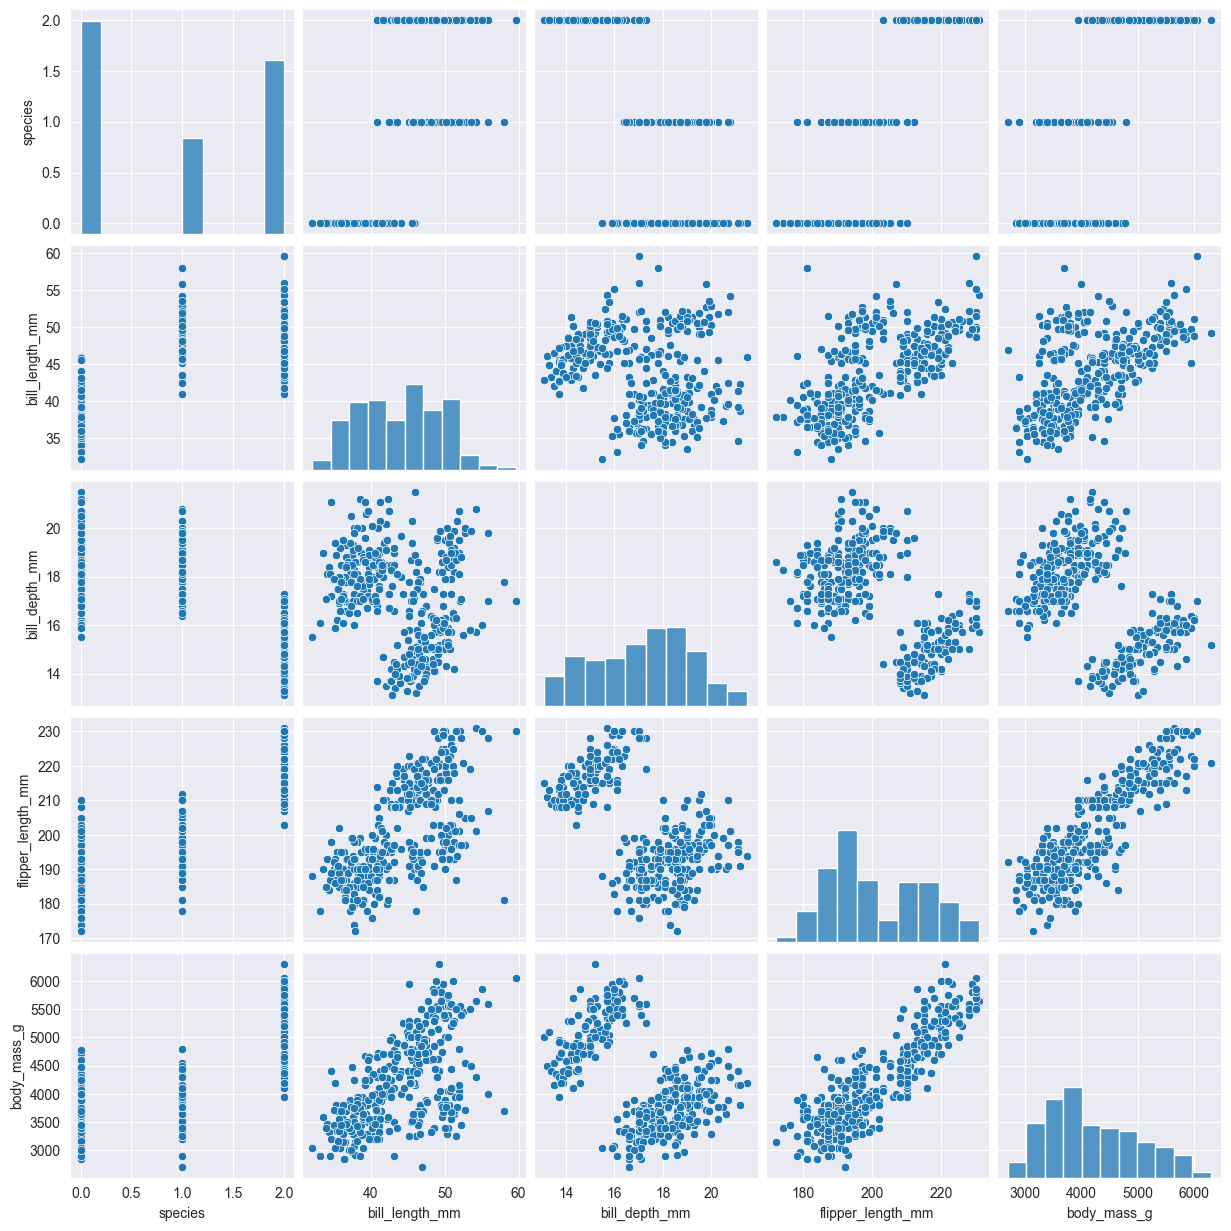

In [406]:
sns.pairplot(pinguins)

**Insight:**
- É possivel verificar que tem variaveis, tais como Body mass, flipper_length, bill depth e bill length, que tem três grupos muito bem definidos.
- A variavel sexo foi deixada no dataset para avaliar, inicialmente, se teria diferença de peso entre as especies.

# Realização da padronização dos dados e visualize os dados.

In [407]:
pinguins_padronizado = pinguins.copy()

In [408]:
colunas_padronizar = ['species','bill_length_mm','bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# Inicializar o StandardScaler
scaler = StandardScaler()
# Ajustar e transformar os dados selecionados
pinguins_padronizado[colunas_padronizar] = scaler.fit_transform(pinguins[colunas_padronizar])

In [409]:
pinguins_padronizado

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-1.030068,-0.884499,0.785449,-1.418347,-0.564142
1,-1.030068,-0.811126,0.126188,-1.062250,-0.501703
2,-1.030068,-0.664380,0.430462,-0.421277,-1.188532
4,-1.030068,-1.324737,1.089724,-0.563715,-0.938776
5,-1.030068,-0.847812,1.748985,-0.777373,-0.689020
...,...,...,...,...,...
338,1.213774,0.601305,-1.750171,0.931890,0.903175
340,1.213774,0.527932,-1.445897,1.003109,0.809516
341,1.213774,1.188289,-0.735923,1.501644,1.933419
342,1.213774,0.234440,-1.192335,0.789451,1.246590


# Aplicação do algoritmo do k means escolhendo o número de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [410]:
kmeans_pinguins = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_pinguins.fit(pinguins_padronizado)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [411]:
centroides = kmeans_pinguins.cluster_centers_
centroides

array([[ 0.02487282,  0.95256426,  0.73927823, -0.30009757, -0.50543075],
       [ 1.21377385,  0.65722922, -1.09998045,  1.15886506,  1.0917612 ],
       [-0.99316225, -0.95171711,  0.5642497 , -0.80548596, -0.6606761 ]])

In [412]:
centroides_padronizados = kmeans_pinguins.cluster_centers_  # Centroides padronizados retornados pelo k-means

# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[9.40298507e-01, 4.91149254e+01, 1.86089552e+01, 1.96701493e+02,
        3.79701493e+03],
       [2.00000000e+00, 4.75048780e+01, 1.49821138e+01, 2.17186992e+02,
        5.07601626e+03],
       [3.28947368e-02, 3.87335526e+01, 1.82638158e+01, 1.89605263e+02,
        3.67269737e+03]])

In [413]:
labels = kmeans_pinguins.labels_
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

# Matriz de dispersão, indicando os pontos e centroides:

Verificação do indice da coluna:

In [414]:
print(pinguins.columns)

Index(['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='str')


**Gráfico de dispersão com as variaveis bill_length_mm e bill_depth_mm:**

In [415]:
# Criando um df com os dados originais e rótulos de cluster
df_clusters = pd.DataFrame({
    'bill_length_mm': pinguins['bill_length_mm'],
    'bill_depth_mm': pinguins['bill_depth_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='bill_length_mm', y='bill_depth_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Pinguins')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 1], y=centroides_originais[:, 2],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Comprimento do bico', yaxis_title='Profundidade do bico',
                  legend_title='Cluster')
fig.show()

**Gráfico de dispersão com as variaveis body_mass_g e species:**

In [416]:
# Criando um df com os dados originais e rótulos de cluster
df_clusters = pd.DataFrame({
    'body_mass_g': pinguins['body_mass_g'],
    'species': pinguins['species'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='body_mass_g', y='species', color='cluster',
                 opacity=0.7,
                 title='Clusters de Pinguins segundo especie e Massa corporal')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 4], y=centroides_originais[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Massa corporal ', yaxis_title='Especies',
                  legend_title='Especies:')
fig.show()

In [417]:
pinguins['cluster'] = labels

In [418]:
medias_por_cluster = pinguins.groupby('cluster')[['bill_length_mm', 'bill_depth_mm']].mean()

In [419]:
medias_por_cluster

,bill_length_mm,bill_depth_mm
cluster,,
0,49.114925,18.608955
1,47.504878,14.982114
2,38.733553,18.263816


**Comparação entre os clusters e especies, para verificar possiveis erros de identificação:**

In [420]:
comparacao = pd.crosstab(pinguins['species'], pinguins['cluster'])

print(comparacao)

cluster   0    1    2
species              
0         4    0  147
1        63    0    5
2         0  123    0


**Espécie do pinguim:**
- **Adelie:** 0
- **Chinstrap:** 1
- **Gentoo:** 2

**INSIGHTS:**
- As características físicas utilizadas no modelo diferenciam bem os pinguins Adelie das outras espécies.
- A espécie Gentoo apresenta características físicas muito distintas, permitindo ao algoritmo separá-la perfeitamente.
- Existe pequena sobreposição entre Chinstrap e Adelie, indicando que algumas medidas corporais são semelhantes entre essas espécies.


- A clusterização conseguiu separar bem as espécies de pinguins. O cluster 1 identificou perfeitamente os indivíduos da espécie Gentoo, enquanto os clusters 0 e 2 representaram majoritariamente Chinstrap e Adelie. Pequenas sobreposições indicam similaridade entre algumas características físicas dessas duas espécies, o que é esperado em dados biológicos.